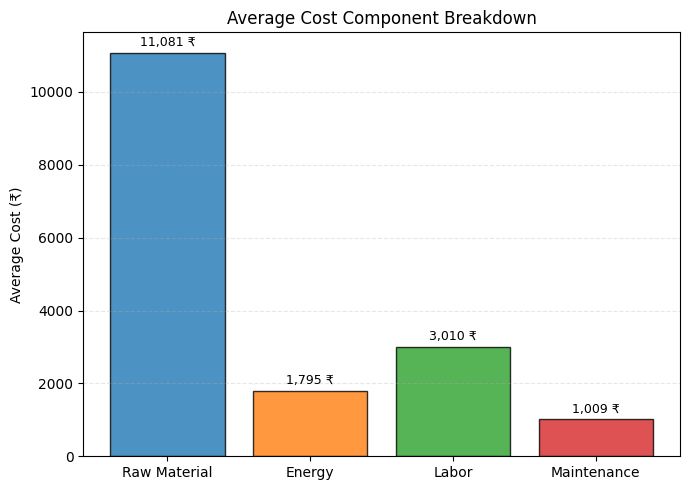

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Option 1: Load your real/saved dataset (uncomment if you have it)
# df = pd.read_csv("food_processing_data.csv")

# Option 2: Generate synthetic data (for demonstration)
np.random.seed(42)
n = 24  # 24 months

df = pd.DataFrame({
    "raw_material_cost": np.random.uniform(8000, 15000, n),
    "energy_cost": np.random.uniform(1200, 2500, n),
    "labor_cost": np.random.uniform(2000, 4000, n),
    "maintenance_cost": np.random.uniform(500, 1500, n),
})

# Compute average for each cost component
avg_raw = df["raw_material_cost"].mean()
avg_energy = df["energy_cost"].mean()
avg_labor = df["labor_cost"].mean()
avg_maint = df["maintenance_cost"].mean()

labels = ["Raw Material", "Energy", "Labor", "Maintenance"]
values = [avg_raw, avg_energy, avg_labor, avg_maint]

# --- Bar chart for cost components (Fig. 3) ---
plt.figure(figsize=(7, 5))
bars = plt.bar(labels, values,
               color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"],
               edgecolor="black", alpha=0.8)

# Optional: add value labels on top of bars
for i, bar in enumerate(bars):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f"{int(values[i]):,} ₹", fontsize=9, ha="center", va="bottom")

plt.ylabel("Average Cost (₹)")
plt.title("Average Cost Component Breakdown")
plt.grid(axis="y", alpha=0.3, linestyle="--")
plt.tight_layout()

# Save the figure (this matches your IEEE caption)
plt.savefig("fig3_cost_components.png", dpi=300, bbox_inches="tight")
plt.show()

Random Forest - MAE: 3687.57 ₹, R²: 0.776


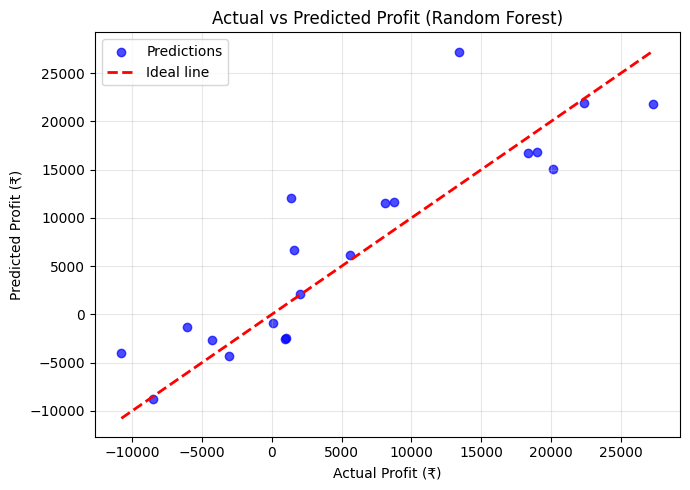

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# --- 1. Load your dataset ---
# Columns needed: raw_material_cost, energy_cost, labor_cost,
# maintenance_cost, production_quantity, revenue, profit, profit_margin

# Option 1: Load your real/saved dataset (uncomment if you have it)
# df = pd.read_csv("food_processing_data.csv")

# Option 2: Generate synthetic data (for demonstration)
np.random.seed(42)
n_samples = 100 # Number of data points

df = pd.DataFrame({
    "raw_material_cost": np.random.uniform(8000, 15000, n_samples),
    "energy_cost": np.random.uniform(1200, 2500, n_samples),
    "labor_cost": np.random.uniform(2000, 4000, n_samples),
    "maintenance_cost": np.random.uniform(500, 1500, n_samples),
    "production_quantity": np.random.randint(1000, 5000, n_samples),
})

# Generate revenue and profit based on other costs and production
df["revenue"] = df["production_quantity"] * np.random.uniform(5, 10, n_samples)
df["total_cost"] = df["raw_material_cost"] + df["energy_cost"] + df["labor_cost"] + df["maintenance_cost"]
df["profit"] = df["revenue"] - df["total_cost"]
df["profit_margin"] = (df["profit"] / df["revenue"]) * 100

# --- 2. Prepare features (X) and target (y) ---
# Use cost and production features to predict profit
X = df[[
    "raw_material_cost",
    "energy_cost",
    "labor_cost",
    "maintenance_cost",
    "production_quantity"
]]

y = df["profit"]  # this is your actual profit (₹)

# --- 3. Split data into train and test ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- 4. Train Random Forest model ---
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# --- 5. Predict on test set ---
y_pred = model.predict(X_test)

# --- 6. Evaluate model ---
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Random Forest - MAE: {mae:.2f} ₹, R²: {r2:.3f}")

# --- 7. Plot Actual vs Predicted Profit (Fig. 4) ---
plt.figure(figsize=(7, 5))

# Scatter of actual vs predicted
plt.scatter(y_test, y_pred, alpha=0.7, color="blue", label="Predictions")

# Ideal line (y = x)
min_val, max_val = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val],
         color="red", linestyle="--", linewidth=2, label="Ideal line")

plt.xlabel("Actual Profit (₹)")
plt.ylabel("Predicted Profit (₹)")
plt.title("Actual vs Predicted Profit (Random Forest)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save figure (this matches your IEEE caption)
plt.savefig("fig4_actual_vs_predicted_profit.png", dpi=300, bbox_inches="tight")
plt.show()

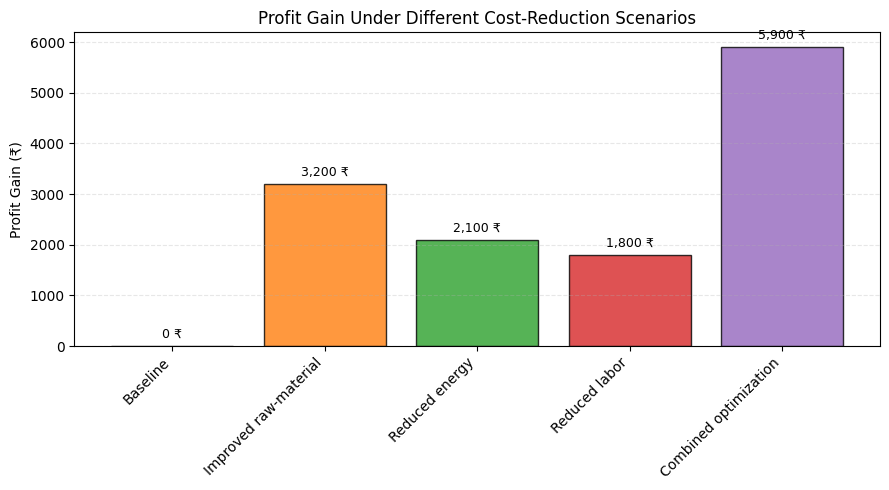

In [ ]:
import matplotlib.pyplot as plt

# Example profit gains (₹) under different scenarios
scenarios = [
    "Baseline",
    "Improved raw-material",
    "Reduced energy",
    "Reduced labor",
    "Combined optimization"
]
profit_gain = [0, 3200, 2100, 1800, 5900]  # gain in ₹ (you can adjust)

# --- Bar chart for profit gain (Fig. 5) ---
plt.figure(figsize=(9, 5))
bars = plt.bar(scenarios, profit_gain,
               color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"],
               edgecolor="black", alpha=0.8)

# Add value labels on top of bars
for i, bar in enumerate(bars):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f"{int(profit_gain[i]):,} ₹", fontsize=9, ha="center", va="bottom")

plt.ylabel("Profit Gain (₹)")
plt.title("Profit Gain Under Different Cost‑Reduction Scenarios")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3, linestyle="--")
plt.tight_layout()

# Save figure (this matches your IEEE caption)
plt.savefig("fig5_profit_gain_scenarios.png", dpi=300, bbox_inches="tight")
plt.show()